In [26]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [28]:
data = pd.read_csv("university_student_stress_dataset.csv")
y = data["Stress_Level"]

features = ["Screen_Time", "Family_Support", "Assignment_Load", "Exam_Frequency", "Anxiety_Level", "Social_Media_Use", "Sleep_Hours"]
X = data[features].copy()

print(X.isnull().sum())
#No null values so no need to fill missing values
print(X.head())

Screen_Time         0
Family_Support      0
Assignment_Load     0
Exam_Frequency      0
Anxiety_Level       0
Social_Media_Use    0
Sleep_Hours         0
dtype: int64
   Screen_Time  Family_Support  Assignment_Load  Exam_Frequency  \
0            9               3                4               7   
1            8               7                8               6   
2            9               5                6               3   
3            6               6                6               8   
4            7               6                1               5   

   Anxiety_Level  Social_Media_Use  Sleep_Hours  
0              5                 6            6  
1              8                 6            5  
2              3                 7            5  
3              5                 5            8  
4              2                 0            6  


In [29]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



Training set size: (2400, 7)
Testing set size: (600, 7)
Training set size: (2400, 7)
Testing set size: (600, 7)
Training set size: (2400, 7)
Testing set size: (600, 7)
Training set size: (2400, 7)
Testing set size: (600, 7)
Training set size: (2400, 7)
Testing set size: (600, 7)
Average Accuracy:  0.8540
Average Precision: 0.8801
Average Recall:    0.7729
Average F1 Macro:  0.8070
Average ROC-AUC:   0.9610


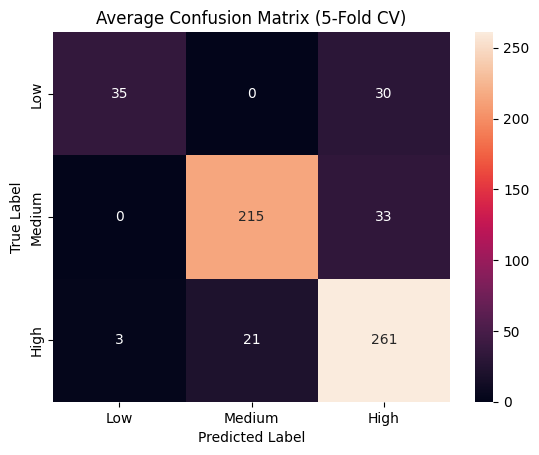

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix
import numpy as np

accuracies, precisions, recalls, f1s, roc_aucs = [], [], [], [], []
conf_matrices = []

for train, test in skf.split(X, y):
    X_train, X_test = X.iloc[train], X.iloc[test]
    y_train, y_test = y.iloc[train], y.iloc[test]

    print("Training set size:", X_train.shape)
    print("Testing set size:", X_test.shape)
    model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average="macro"))
    recalls.append(recall_score(y_test, y_pred, average="macro"))
    f1s.append(f1_score(y_test, y_pred, average="macro"))
    roc_aucs.append(roc_auc_score(y_test, y_pred_proba, multi_class="ovr"))
    conf_matrices.append(confusion_matrix(y_test, y_pred))

print(f"Average Accuracy:  {np.mean(accuracies):.4f}")
print(f"Average Precision: {np.mean(precisions):.4f}")
print(f"Average Recall:    {np.mean(recalls):.4f}")
print(f"Average F1 Macro:  {np.mean(f1s):.4f}")
print(f"Average ROC-AUC:   {np.mean(roc_aucs):.4f}")

# Average confusion matrix across folds
avg_conf = np.mean(conf_matrices, axis=0).astype(int)
sb.heatmap(avg_conf, annot=True, fmt="d", xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])
plt.title("Average Confusion Matrix (5-Fold CV)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [31]:
final_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
    # add best params from GridSearch here if you ran it
)

final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
sample = X.iloc[[0]] 
final_model.predict(sample)

array(['Medium'], dtype=object)